In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import cv2
import os

In [2]:
project_root = Path().resolve()
data_root = project_root / "data"

train_dir = data_root / "train"
valid_dir = data_root / "valid"
test_dir = data_root / "test"

train_csv = train_dir / "_annotations.csv"
valid_csv = valid_dir / "_annotations.csv"
test_csv = test_dir / "_annotations.csv"

print("Train exists:", train_dir.exists())
print("Valid exists:", valid_dir.exists())
print("Test exists:", test_dir.exists())

Train exists: True
Valid exists: True
Test exists: True


In [3]:
train_df = pd.read_csv(train_csv)
valid_df = pd.read_csv(valid_csv)
test_df = pd.read_csv(test_csv)

print("Train shape:", train_df.shape)
print("Valid shape:", valid_df.shape)
print("Test shape:", test_df.shape)

Train shape: (1761, 8)
Valid shape: (500, 8)
Test shape: (264, 8)


In [4]:
train_df.head()

,filename,width,height,class,xmin,ymin,xmax,ymax
0,plastic470_jpg.rf.340ed4f42f37e959a6e079fe03bb...,384,384,plastic,31,35,288,341
1,plastic54_jpg.rf.40d253a859edf299abc7e16926635...,384,384,plastic,1,0,383,384
2,plastic40_jpg.rf.6a480ad9d0a852391afac660adf08...,384,384,plastic,0,0,340,346
3,plastic252_jpg.rf.0048f12a261646f67a01a1ccedd0...,384,384,plastic,31,55,371,384
4,glass422_jpg.rf.08174e29ebc59df33229a67294654e...,384,384,glass,62,54,244,293


In [5]:
print("Train classes:", sorted(train_df["class"].unique()))
print("Valid classes:", sorted(valid_df["class"].unique()))
print("Test classes:", sorted(test_df["class"].unique()))

Train classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Valid classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Test classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [6]:
print("Train images:", train_df["filename"].nunique())
print("Valid images:", valid_df["filename"].nunique())
print("Test images:", test_df["filename"].nunique())

Train images: 1761
Valid images: 499
Test images: 264


In [7]:
train_class_counts = train_df["class"].value_counts()
print(train_class_counts)

class
paper        417
glass        349
plastic      333
metal        285
cardboard    283
trash         94
Name: count, dtype: int64


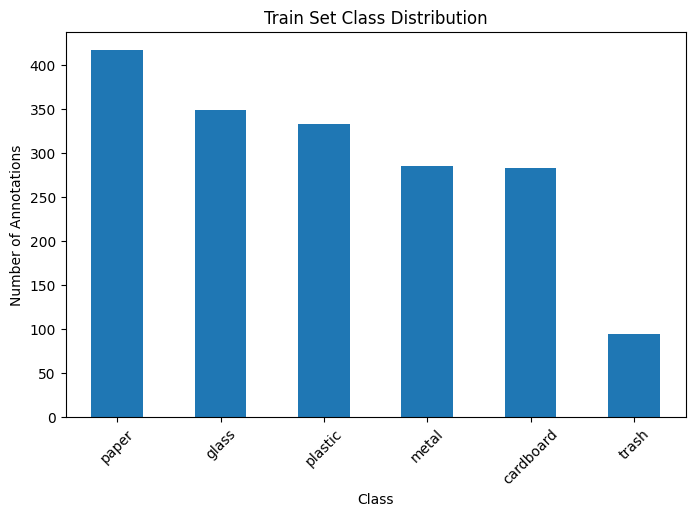

In [8]:
train_class_counts.plot(kind="bar", figsize=(8, 5))
plt.title("Train Set Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Annotations")
plt.xticks(rotation=45)
plt.show()

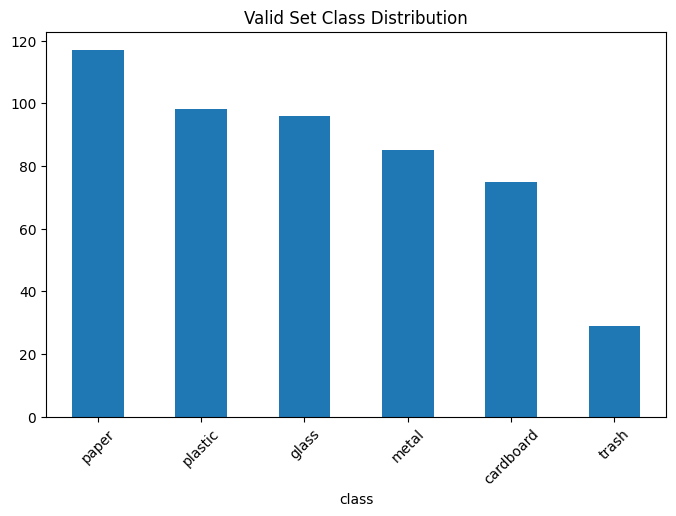

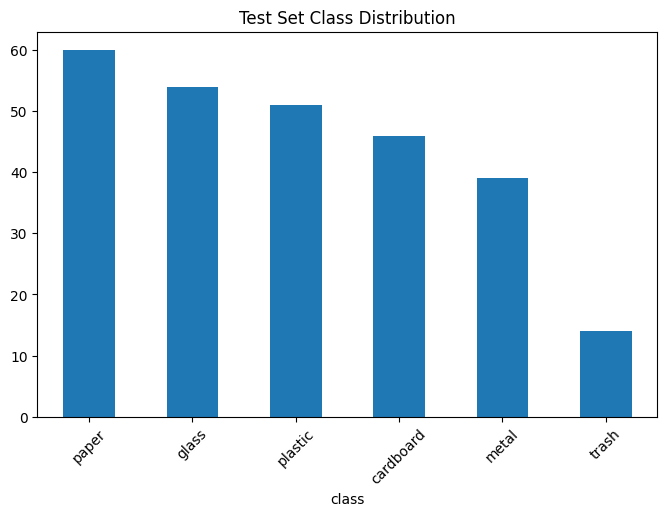

In [9]:
valid_df["class"].value_counts().plot(kind="bar", figsize=(8, 5), title="Valid Set Class Distribution")
plt.xticks(rotation=45)
plt.show()

test_df["class"].value_counts().plot(kind="bar", figsize=(8, 5), title="Test Set Class Distribution")
plt.xticks(rotation=45)
plt.show()

In [11]:
for df in [train_df, valid_df, test_df]:
    df["box_width"] = df["xmax"] - df["xmin"]
    df["box_height"] = df["ymax"] - df["ymin"]
    df["box_area"] = df["box_width"] * df["box_height"]

train_df[["box_width", "box_height", "box_area"]].describe()

,box_width,box_height,box_area
count,1761.000000,1761.000000,1761.000000
mean,309.638274,328.679727,104199.316298
std,70.858753,59.009809,35147.340831
min,91.000000,131.000000,12285.000000
25%,256.000000,295.000000,77748.000000
50%,324.000000,346.000000,106733.000000
75%,384.000000,384.000000,138240.000000
max,384.000000,384.000000,147456.000000


In [12]:
invalid_boxes = train_df[
    (train_df["xmin"] >= train_df["xmax"]) |
    (train_df["ymin"] >= train_df["ymax"]) |
    (train_df["xmin"] < 0) |
    (train_df["ymin"] < 0) |
    (train_df["xmax"] > train_df["width"]) |
    (train_df["ymax"] > train_df["height"])
]

print("Invalid boxes in train:", len(invalid_boxes))
invalid_boxes.head()

Invalid boxes in train: 0


,filename,width,height,class,xmin,ymin,xmax,ymax,box_width,box_height,box_area


In [13]:
print("Train image sizes:")
print(train_df[["width", "height"]].drop_duplicates())

Train image sizes:
   width  height
0    384     384


In [14]:
objects_per_image = train_df.groupby("filename").size()

print(objects_per_image.describe())

count    1761.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
dtype: float64


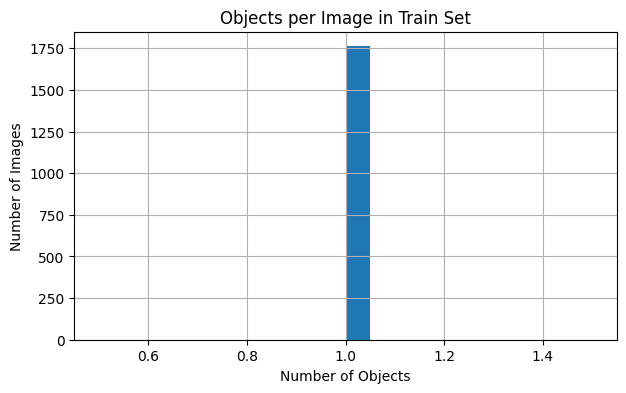

In [15]:
objects_per_image.hist(figsize=(7, 4), bins=20)
plt.title("Objects per Image in Train Set")
plt.xlabel("Number of Objects")
plt.ylabel("Number of Images")
plt.show()

In [16]:
import random

def show_sample(split_dir, df, n=3):
    sample_files = random.sample(list(df["filename"].unique()), n)

    for filename in sample_files:
        rows = df[df["filename"] == filename]
        image_path = split_dir / filename
        image = cv2.imread(str(image_path))

        if image is None:
            print(f"Could not read {image_path}")
            continue

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        for _, row in rows.iterrows():
            xmin, ymin, xmax, ymax = int(row["xmin"]), int(row["ymin"]), int(row["xmax"]), int(row["ymax"])
            class_name = row["class"]

            cv2.rectangle(image, (xmin, ymin), (xmax, ymax), (0, 255, 0), 2)
            cv2.putText(
                image,
                class_name,
                (xmin, max(ymin - 10, 20)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (0, 255, 0),
                2
            )

        plt.figure(figsize=(6, 6))
        plt.imshow(image)
        plt.title(filename)
        plt.axis("off")
        plt.show()

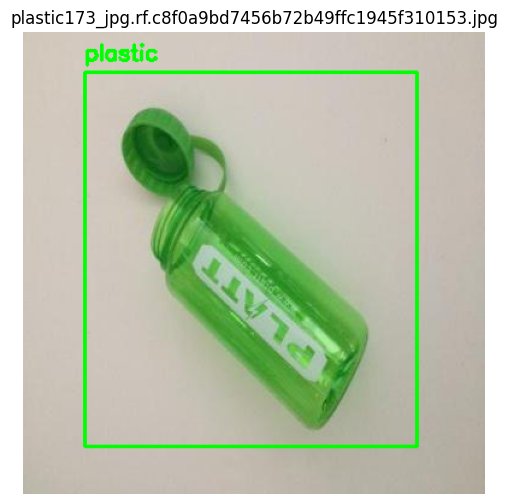

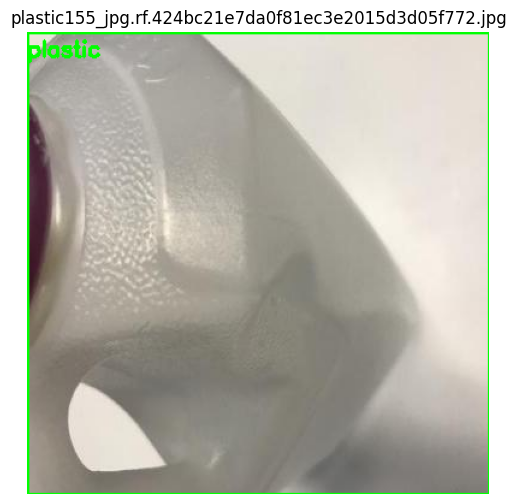

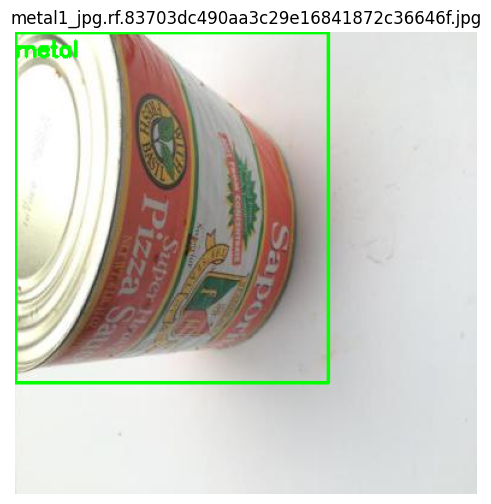

In [17]:
show_sample(train_dir, train_df, n=3)

In [18]:
train_df.groupby("class")["box_area"].mean().sort_values()

class
trash         83945.670213
glass         84490.108883
plastic       91697.315315
metal         93127.371930
paper        120391.712230
cardboard    137233.936396
Name: box_area, dtype: float64

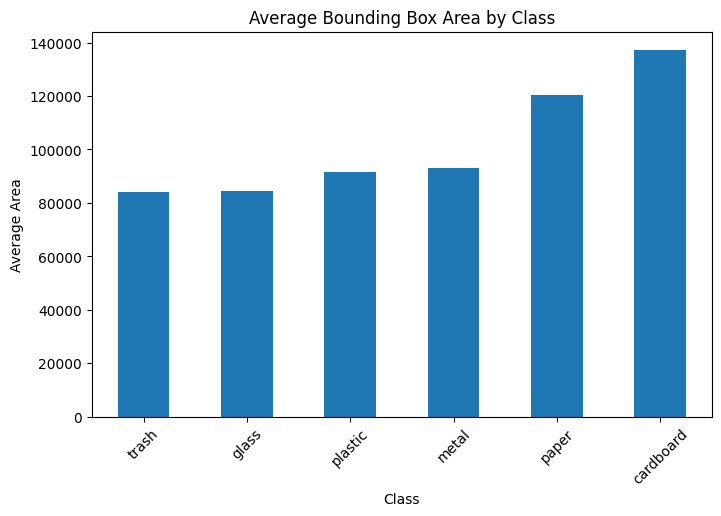

In [19]:
train_df.groupby("class")["box_area"].mean().sort_values().plot(kind="bar", figsize=(8, 5))
plt.title("Average Bounding Box Area by Class")
plt.xlabel("Class")
plt.ylabel("Average Area")
plt.xticks(rotation=45)
plt.show()

In [20]:
class_counts = train_df["class"].value_counts()
print("Most common class:", class_counts.idxmax(), "-", class_counts.max())
print("Least common class:", class_counts.idxmin(), "-", class_counts.min())

Most common class: paper - 417
Least common class: trash - 94
